# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay,
    make_scorer
)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.inspection import permutation_importance

# Preprocessing

In [2]:
df_raw = pd.read_excel("1 - Project Data.xlsx")

In [3]:
df_raw.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Reason'],
      dtype='str')

In [4]:
cols_all = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
           'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
           'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
           'Multiple Lines', 'Internet Service', 'Online Security',
           'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
           'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
           'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
           'Churn Reason']


cols_drop = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Lat Long',
             'Latitude', 'Longitude', 'Churn Label', 'Churn Reason', 'Zip Code']

cols_keep = ['Phone Service', 'Internet Service', 'Total Charges', 'Paperless Billing', 
             'Partner', 'Online Backup', 'Multiple Lines', 'Monthly Charges', 'Churn Value',
             'Contract', 'Tech Support', 'Online Security', 'Device Protection',
             'Dependents', 'Senior Citizen', 'Gender', 'Streaming TV', 
             'Payment Method', 'Streaming Movies', 'Tenure Months']


target = ["Churn Value"]

cols_cat = ['Gender','Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 
            'Paperless Billing', 'Multiple Lines', 'Internet Service', 
            'Online Security', 'Online Backup', 'Device Protection',
            'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract',
            'Payment Method']

cols_num = ['Monthly Charges', 'Total Charges', 'Tenure Months']


cols_new = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Paperless Billing_Yes',
       'Multiple Lines_No phone service', 'Multiple Lines_Yes',
       'Internet Service_Fiber optic', 'Internet Service_No',
       'Online Security_No internet service', 'Online Security_Yes',
       'Online Backup_No internet service', 'Online Backup_Yes',
       'Device Protection_No internet service', 'Device Protection_Yes',
       'Tech Support_No internet service', 'Tech Support_Yes',
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check']

In [5]:
print(len(cols_all))
print(len(cols_drop))
print(len(cols_keep))
print(len(cols_cat))
print(len(cols_num))
print(len(target))

31
11
20
16
3
1


In [6]:
def clean(df, cols_drop, cols_cat, cols_num):

    # Make a copy 
    df = df.copy()
    
    # Drop columns we don't need
    df = df.drop(cols_drop, axis=1)

    # Convert Total Charges to numeric
    df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

    # Replace NaN with 0
    df = df.fillna(0)

    # One-hot encode categorical columns
    for col in cols_cat:
        dummies = pd.get_dummies(
            df[col],
            prefix=col,
            drop_first=True,
            dtype=int
        )
        df = pd.concat([df.drop(columns=col), dummies], axis=1)
        
    return df

# Modelling

In [7]:
df = clean(df_raw,cols_drop,cols_cat,cols_num)

In [8]:
X = df.drop(columns = target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

`precision_at_k_fraction`: The main goal of our model is to predict the top 500 most likely to churn customers out of the 5174 remaining customers. We can evaluate our models performance on this task on any subset of the dataset as follows. 

Take a subset of the dataset (validation/test set) of size $n$. We want the top $\frac{500}{5174} = 0.097 = k$ most likely. We rank our subset based on predicted probability of churning and examine the top $n*k$ customers. We then calculate how many of those customers actually churned and that is our precision at k-fraction.

In [9]:
TOP_K_FRACTION = 500 / 5174  # ~0.097

def precision_at_k_fraction(y_true, y_proba, k_fraction=TOP_K_FRACTION):
    y_true = np.asarray(y_true)
    n_top = max(1, int(round(len(y_true) * k_fraction)))
    top_idx = np.argsort(y_proba)[::-1][:n_top]
    return y_true[top_idx].mean()

precision_at_k_scorer = make_scorer(
    precision_at_k_fraction, response_method="predict_proba", greater_is_better=True
)

## Logistic Regression

In [10]:
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), cols_num)],
    remainder='passthrough'
)

pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, random_state=42)),
    ]
)

param_grid = {
    "clf__C": [0.1,1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
    "clf__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "precision_at_k": precision_at_k_scorer,
    "average_precision": "average_precision",
    "f1": "f1",
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

In [11]:
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV ROC AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\gerai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best params: {'clf__C': 100, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best CV ROC AUC: 0.8592


In [12]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values("mean_test_roc_auc", ascending=False)
print(
    cv_results_sorted[
        ["params", "mean_test_roc_auc", "std_test_roc_auc","mean_test_precision_at_k"
         , "mean_test_average_precision", "mean_test_f1"]
    ].head(20).to_string(index=False)
)

                                                                                            params  mean_test_roc_auc  std_test_roc_auc  mean_test_precision_at_k  mean_test_average_precision  mean_test_f1
      {'clf__C': 100, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}           0.859208          0.012769                  0.794495                     0.678448      0.621472
      {'clf__C': 100, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}           0.859191          0.012824                  0.794495                     0.678274      0.621241
       {'clf__C': 10, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}           0.859099          0.012746                  0.790826                     0.679208      0.621176
       {'clf__C': 10, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}           0.859081          0.012738                  0.787156                   

Not much difference in ROC/AUC, marginally better `precision_at_k_fraction` for `C=1`. 

In [13]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', class_weight='balanced', C=1, solver='liblinear'))
])

lr_pipe.fit(X_train, y_train)

C:\Users\gerai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred = lr_pipe.predict(X_test)
y_proba = lr_pipe.predict_proba(X_test)[:, 1]
print("\nTest set performance:")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"Precision on top 10%: {precision_at_k_fraction(y_test, y_proba)}")


Test set performance:
ROC AUC: 0.8491
Confusion matrix:
[[757 278]
 [ 82 292]]
Precision on top 10%: 0.7794117647058824


# GB Decision Forest

## Tuning

In [15]:
pipe = Pipeline(
    steps=[
        ("clf", HistGradientBoostingClassifier(random_state=42)),
    ]
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "precision_at_k": precision_at_k_scorer,
    "average_precision": "average_precision",
    "f1": "f1",
}

In [16]:
param_distributions = {
    "clf__learning_rate": [0.03],
    "clf__max_iter": [100, 200, 300],
    "clf__max_depth": [3],
    "clf__min_samples_leaf": [50, 100],
    "clf__class_weight": [None, "balanced"],
}

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=30,             # Limit to 15 random combinations total!
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-2,             # Use all CPU cores
    random_state=42,
    verbose=2,
)

In [17]:
random_search.fit(X_train, y_train)

C:\Users\gerai\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=30. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\gerai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'clf__class_weight': [None, 'balanced'], 'clf__learning_rate': [0.03], 'clf__max_depth': [3], 'clf__max_iter': [100, 200, ...], ...}"
,n_iter,30
,scoring,"{'average_precision': 'average_precision', 'f1': 'f1', 'precision_at_k': make_scorer(p...redict_proba'), 'roc_auc': 'roc_auc'}"
,n_jobs,-2
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [18]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results_sorted = cv_results.sort_values("mean_test_roc_auc", ascending=False)
print(
    cv_results_sorted[
        ["params", "mean_test_roc_auc", "std_test_roc_auc","mean_test_precision_at_k"
         , "mean_test_average_precision", "mean_test_f1"]
    ].head(10).to_string(index=False)
)

                                                                                                                                params  mean_test_roc_auc  std_test_roc_auc  mean_test_precision_at_k  mean_test_average_precision  mean_test_f1
       {'clf__min_samples_leaf': 50, 'clf__max_iter': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.03, 'clf__class_weight': None}           0.863971          0.011559                  0.772477                     0.687490      0.595808
       {'clf__min_samples_leaf': 50, 'clf__max_iter': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.03, 'clf__class_weight': None}           0.863798          0.011476                  0.770642                     0.690187      0.611711
      {'clf__min_samples_leaf': 100, 'clf__max_iter': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.03, 'clf__class_weight': None}           0.863771          0.011249                  0.770642                     0.687329      0.597186
 {'clf__min_samples_leaf': 50, 'clf_

Not too much difference here either. Doesnt seem to be a preference for `class_weight` however we know that `class_weight = "balanced"` can inflate predicted probabilities, and since ROC/AUC and `precision_at_k_fraction` are rank based metrics (they measure the performance of the models relative predicted probabilities, not the absolute ones), we will plot reliability curves to investigate and compare the absolute performance of the models predictions.

## Reliability

In [19]:
model_balanced = Pipeline(steps=[
    ("preprocess", preprocessor),  # your existing preprocessing pipeline
    ("clf", HistGradientBoostingClassifier(
        min_samples_leaf=50, max_iter=300, max_depth=3,
        learning_rate=0.03, class_weight="balanced", random_state=42
    ))
])

model_unweighted = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", HistGradientBoostingClassifier(
        min_samples_leaf=50, max_iter=300, max_depth=3,
        learning_rate=0.03, class_weight=None, random_state=42
    ))
])

In [20]:
model_balanced.fit(X_train, y_train)
model_unweighted.fit(X_train, y_train)

# Get predicted probabilities for the positive (churn) class
proba_balanced = model_balanced.predict_proba(X_test)[:, 1]
proba_unweighted = model_unweighted.predict_proba(X_test)[:, 1]

C:\Users\gerai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\gerai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


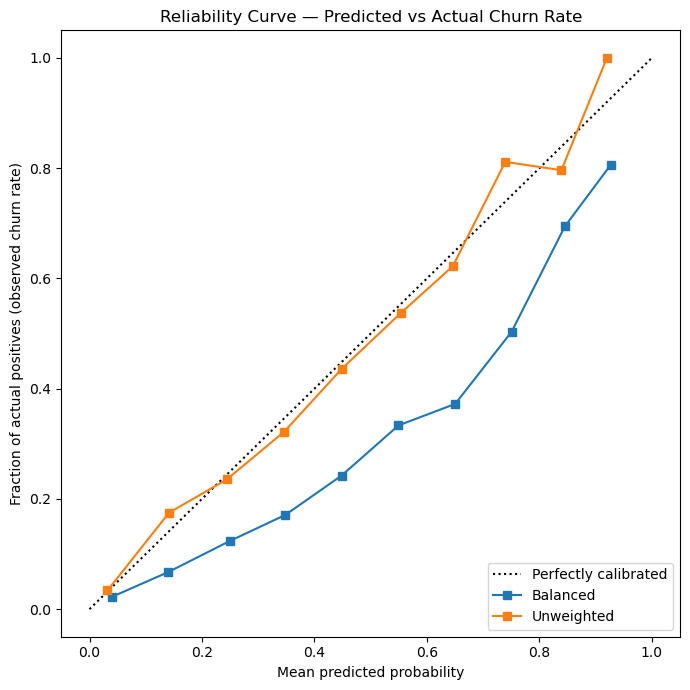

In [21]:
# --- Plot reliability curves for both models side by side ---
fig, ax = plt.subplots(figsize=(7, 7))

CalibrationDisplay.from_predictions(
    y_test, proba_balanced, n_bins=10, name="Balanced", ax=ax
)
CalibrationDisplay.from_predictions(
    y_test, proba_unweighted, n_bins=10, name="Unweighted", ax=ax
)

ax.set_title("Reliability Curve — Predicted vs Actual Churn Rate")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of actual positives (observed churn rate)")
plt.tight_layout()
plt.savefig("reliability_curve.png", dpi=150)
plt.show()

# --- Also print the raw bin values, useful for the appendix/slide ---
frac_pos_bal, mean_pred_bal = calibration_curve(y_test, proba_balanced, n_bins=10)
frac_pos_unw, mean_pred_unw = calibration_curve(y_test, proba_unweighted, n_bins=10)

Clearly more accurate probabilities predicted with unweighted model.

# Best Model

In [22]:
best_HGB = HistGradientBoostingClassifier(min_samples_leaf=100, max_iter=300, max_depth=5, learning_rate=0.05, class_weight=None, random_state=42)
best_HGB.fit(X_train,y_train)

C:\Users\gerai\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'log_loss'
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,5
,min_samples_leaf,100
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [23]:
# 3. Make Predictions on Test Data
# --------------------------------
# Get class predictions (0 or 1)
y_pred = best_HGB.predict(X_test)

# Get predicted probabilities (useful for ROC-AUC, precision-recall curves, etc.)
y_proba = best_HGB.predict_proba(X_test)[:, 1]

In [24]:
print("\n--- Test Set Results ---")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Test Precision on top 9.7%: {precision_at_k_fraction(y_test,y_proba)}")


--- Test Set Results ---
Test ROC-AUC: 0.8527
Test Precision on top 9.7%: 0.7794117647058824


`precision_at_k_fraction` Is roughly the same as our logistic regression model, however ROC/AUC is better for our gradient boosted decision forest.

# Model Outputs

In [25]:
current_customers_clean = df[df['Churn Value'] == 0].drop("Churn Value", axis = 1)
current_customers_raw = df_raw[df_raw['Churn Value'] == 0]

In [26]:
preds = best_HGB.predict_proba(current_customers_clean)[:, 1]
print(preds)

[0.74402527 0.01479884 0.02225616 ... 0.00094503 0.24035721 0.2858813 ]


In [27]:
predicted_prob_churn = pd.DataFrame()
predicted_prob_churn["Customer ID"] = current_customers_raw["CustomerID"]
predicted_prob_churn["Probability of Churning"] = best_HGB.predict_proba(current_customers_clean)[:, 1]
predicted_prob_churn.head()

,Customer ID,Probability of Churning
1869,7590-VHVEG,0.744025
1870,5575-GNVDE,0.014799
1871,7795-CFOCW,0.022256
1872,1452-KIOVK,0.145611
1873,6713-OKOMC,0.196932


In [28]:
predicted_prob_churn.to_csv("Model Predictions.csv", index = False)

In [29]:
most_likely_churners = predicted_prob_churn.sort_values("Probability of Churning", ascending = False).head(500).drop("Probability of Churning", axis = 1)

In [38]:
most_likely_churners.to_csv("Most Likely Churners.csv", index = False)

# Feature Importance

 We will now investigate the feature importance of these models.

## Decision Forest

In [31]:
perm_result = permutation_importance(
    best_HGB, X_test, y_test,
    scoring=precision_at_k_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

hgb_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print(hgb_importance.to_string(index=False))

                               feature  importance_mean  importance_std
                         Tenure Months         0.181618        0.027325
                        Dependents_Yes         0.071324        0.020810
                         Total Charges         0.047794        0.018086
                     Contract_One year         0.044853        0.013736
                     Contract_Two year         0.041912        0.022071
          Internet Service_Fiber optic         0.041176        0.015141
                       Monthly Charges         0.028676        0.026603
                   Internet Service_No         0.025735        0.008221
                   Online Security_Yes         0.023529        0.012216
       Payment Method_Electronic check         0.022059        0.006577
                 Paperless Billing_Yes         0.013971        0.016260
                      Tech Support_Yes         0.013971        0.012060
                     Phone Service_Yes         0.011765        0

## Logistic Regression

In [32]:
# Assumes your fitted pipeline is called `lr_pipe` with steps 
# named 'preprocessor' and 'classifier' (adjust names if different)
feature_names = lr_pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = lr_pipe.named_steps['classifier'].coef_[0]

lr_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'odds_ratio': np.exp(coefs),
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print(lr_importance.head(20).to_string(index=False))

                                        feature  coefficient  odds_ratio  abs_coef
                      remainder__Dependents_Yes    -1.630766    0.195780  1.630766
                   remainder__Contract_Two year    -1.405450    0.245257  1.405450
                             num__Tenure Months    -1.196596    0.302221  1.196596
                   remainder__Contract_One year    -0.785241    0.456010  0.785241
        remainder__Internet Service_Fiber optic     0.689186    1.992092  0.689186
                 remainder__Internet Service_No    -0.604209    0.546506  0.604209
                   remainder__Phone Service_Yes    -0.534946    0.585701  0.534946
                             num__Total Charges     0.499514    1.647920  0.499514
                 remainder__Online Security_Yes    -0.386081    0.679716  0.386081
     remainder__Payment Method_Electronic check     0.384285    1.468564  0.384285
                    remainder__Tech Support_Yes    -0.350391    0.704412  0.350391
    

In [35]:
passthrough_features = [c for c in X_train.columns if c not in cols_num]
feature_names = cols_num + passthrough_features

lr_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_pipe.named_steps['classifier'].coef_[0],
    'odds_ratio': np.exp(lr_pipe.named_steps['classifier'].coef_[0]),
    'abs_coef': np.abs(lr_pipe.named_steps['classifier'].coef_[0])
}).sort_values('abs_coef', ascending=False)

n_zeroed = (lr_importance['coefficient'] == 0).sum()
print(f"{n_zeroed} of {len(lr_importance)} features zeroed out by L1 penalty\n")
print(lr_importance.to_string(index=False))

2 of 30 features zeroed out by L1 penalty

                               feature  coefficient  odds_ratio  abs_coef
                        Dependents_Yes    -1.630766    0.195780  1.630766
                     Contract_Two year    -1.405450    0.245257  1.405450
                         Tenure Months    -1.196596    0.302221  1.196596
                     Contract_One year    -0.785241    0.456010  0.785241
          Internet Service_Fiber optic     0.689186    1.992092  0.689186
                   Internet Service_No    -0.604209    0.546506  0.604209
                     Phone Service_Yes    -0.534946    0.585701  0.534946
                         Total Charges     0.499514    1.647920  0.499514
                   Online Security_Yes    -0.386081    0.679716  0.386081
       Payment Method_Electronic check     0.384285    1.468564  0.384285
                      Tech Support_Yes    -0.350391    0.704412  0.350391
                 Paperless Billing_Yes     0.314664    1.369800  0.31

In [36]:
print(lr_pipe.named_steps['preprocessor'].get_feature_names_out()[:10])
feature_names[:10]

['num__Monthly Charges' 'num__Total Charges' 'num__Tenure Months'
 'remainder__Gender_Male' 'remainder__Senior Citizen_Yes'
 'remainder__Partner_Yes' 'remainder__Dependents_Yes'
 'remainder__Phone Service_Yes' 'remainder__Paperless Billing_Yes'
 'remainder__Multiple Lines_No phone service']


['Monthly Charges',
 'Total Charges',
 'Tenure Months',
 'Gender_Male',
 'Senior Citizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'Phone Service_Yes',
 'Paperless Billing_Yes',
 'Multiple Lines_No phone service']